# Comparação de trajetórias — Odometria vs Dead Reckoning

Este notebook carrega automaticamente os arquivos `gt.csv`, `odo.csv`, `dr.csv` e `odo_husky.csv` a partir de uma pasta de resultados.

Altere apenas a variável `PASTA_DADOS` para apontar para a pasta gerada pela simulação, por exemplo:

```python
PASTA_DADOS = Path('/home/rafael/odo_vs_dc/resultados/empty_20260503_143351')
```

Este notebook **não salva arquivos PNG automaticamente**. Ele apenas exibe os gráficos na tela.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Altere somente esta variável para a pasta da simulação que deseja analisar.
# Exemplo de pasta gerada com timestamp:
PASTA_DADOS = Path('/home/rafael/odo_vs_dc/resultados/empty_20260503_143351')

def carregar_csv(nome):
    caminho = PASTA_DADOS / nome
    if not caminho.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {caminho}')
    return pd.read_csv(caminho, comment='#')

print(f'Lendo dados de: {PASTA_DADOS}')


Lendo dados de: /home/rafael/odo_vs_dc/resultados/empty_20260503_143351


## 1. Carregar os dados

In [2]:
gt = carregar_csv('gt.csv')
odo = carregar_csv('odo.csv')
dr = carregar_csv('dr.csv')
odo_husky = carregar_csv('odo_husky.csv')

print('Arquivos carregados:')
print(f'gt:        {len(gt)} amostras')
print(f'odo:       {len(odo)} amostras')
print(f'dr:        {len(dr)} amostras')
print(f'odo_husky: {len(odo_husky)} amostras')


Arquivos carregados:
gt:        727 amostras
odo:       727 amostras
dr:        727 amostras
odo_husky: 727 amostras


## 2. Trajetória no plano X-Y

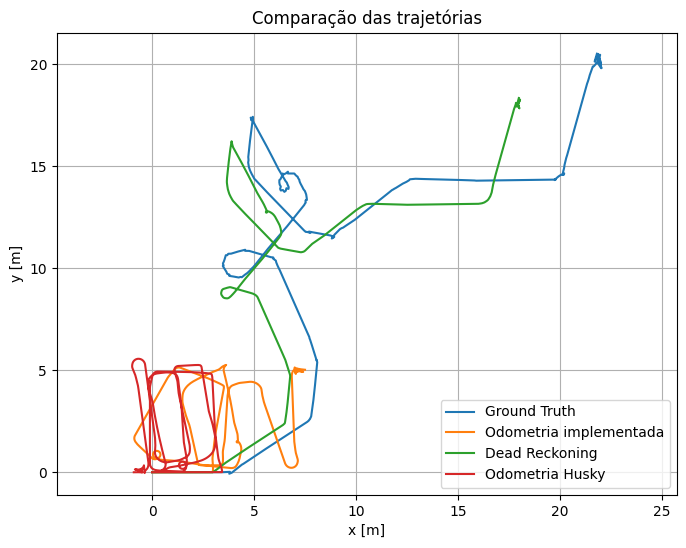

In [3]:
plt.figure(figsize=(8, 6))

plt.plot(gt['field.x'], gt['field.y'], label='Ground Truth')
plt.plot(odo['field.x'], odo['field.y'], label='Odometria implementada')
plt.plot(dr['field.x'], dr['field.y'], label='Dead Reckoning')
plt.plot(odo_husky['field.x'], odo_husky['field.y'], label='Odometria Husky')

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Comparação das trajetórias')
plt.legend()
plt.grid(True)
plt.axis('equal')

plt.show()

## 3. Posição X ao longo do tempo

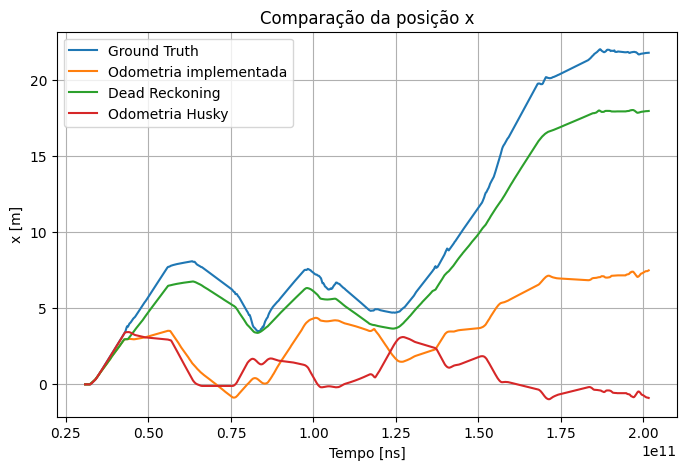

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(gt['%time'], gt['field.x'], label='Ground Truth')
plt.plot(odo['%time'], odo['field.x'], label='Odometria implementada')
plt.plot(dr['%time'], dr['field.x'], label='Dead Reckoning')
plt.plot(odo_husky['%time'], odo_husky['field.x'], label='Odometria Husky')

plt.xlabel('Tempo [ns]')
plt.ylabel('x [m]')
plt.title('Comparação da posição x')
plt.legend()
plt.grid(True)

plt.show()

## 4. Posição Y ao longo do tempo

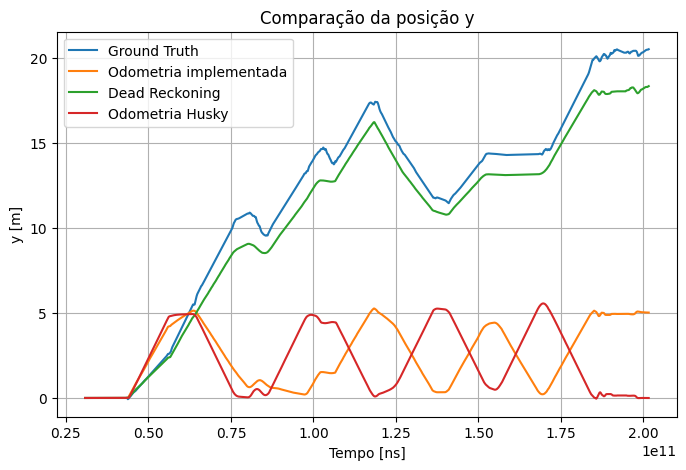

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(gt['%time'], gt['field.y'], label='Ground Truth')
plt.plot(odo['%time'], odo['field.y'], label='Odometria implementada')
plt.plot(dr['%time'], dr['field.y'], label='Dead Reckoning')
plt.plot(odo_husky['%time'], odo_husky['field.y'], label='Odometria Husky')

plt.xlabel('Tempo [ns]')
plt.ylabel('y [m]')
plt.title('Comparação da posição y')
plt.legend()
plt.grid(True)

plt.show()

## 5. Orientação θ ao longo do tempo

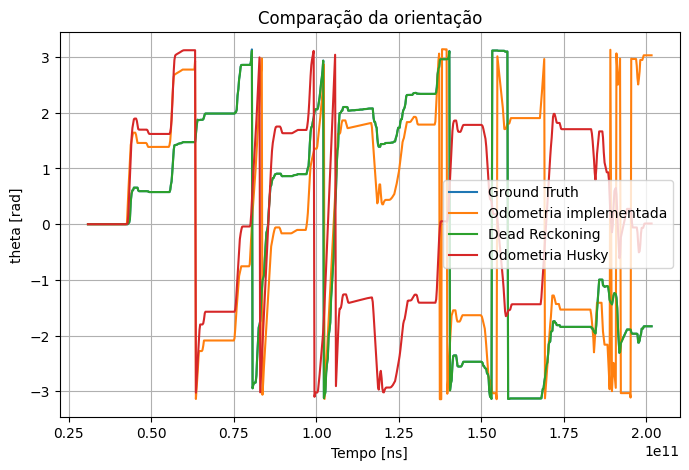

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(gt['%time'], gt['field.z'], label='Ground Truth')
plt.plot(odo['%time'], odo['field.z'], label='Odometria implementada')
plt.plot(dr['%time'], dr['field.z'], label='Dead Reckoning')
plt.plot(odo_husky['%time'], odo_husky['field.z'], label='Odometria Husky')

plt.xlabel('Tempo [ns]')
plt.ylabel('theta [rad]')
plt.title('Comparação da orientação')
plt.legend()
plt.grid(True)

plt.show()

## 6. Trajetória relativa ao ponto inicial

Remove o offset inicial de cada curva para comparar melhor o formato das trajetórias.


In [7]:
def relativo(df):
    df = df.copy()
    df["x_rel"] = df["field.x"] - df["field.x"].iloc[0]
    df["y_rel"] = df["field.y"] - df["field.y"].iloc[0]
    df["theta_rel"] = df["field.z"] - df["field.z"].iloc[0]
    return df

gt_rel = relativo(gt)
odo_rel = relativo(odo)
dr_rel = relativo(dr)
odo_husky_rel = relativo(odo_husky)

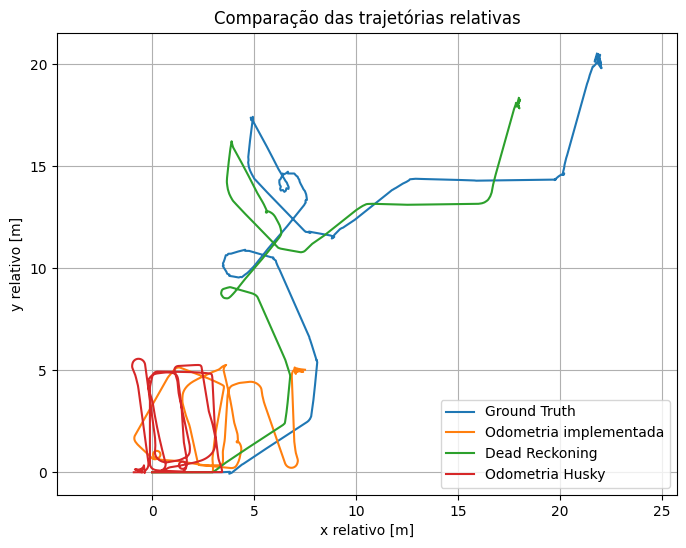

In [8]:
plt.figure(figsize=(8, 6))

plt.plot(gt_rel["x_rel"], gt_rel["y_rel"], label="Ground Truth")
plt.plot(odo_rel["x_rel"], odo_rel["y_rel"], label="Odometria implementada")
plt.plot(dr_rel["x_rel"], dr_rel["y_rel"], label="Dead Reckoning")
plt.plot(odo_husky_rel["x_rel"], odo_husky_rel["y_rel"], label="Odometria Husky")

plt.xlabel("x relativo [m]")
plt.ylabel("y relativo [m]")
plt.title("Comparação das trajetórias relativas")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

## Observação

Nos arquivos `geometry_msgs/Point`, os campos foram usados assim:

- `field.x`: posição no eixo x;
- `field.y`: posição no eixo y;
- `field.z`: orientação `theta`, em radianos.

Nesse caso, `field.z` não representa altura.

Para analisar uma nova simulação, altere apenas `PASTA_DADOS` para o caminho da nova pasta com timestamp.
